In [1]:
import pandas as pd
import numpy as np
import os

BASE_DIR = os.path.expanduser("~/projects/nhs-ae-waiting-times")
GOLD_DIR = os.path.join(BASE_DIR, "data/gold")

# Load all three Gold tables
providers = pd.read_parquet(os.path.join(GOLD_DIR, "gold_ae_provider_monthly.parquet"))
national = pd.read_parquet(os.path.join(GOLD_DIR, "gold_ae_national_monthly.parquet"))
regional = pd.read_parquet(os.path.join(GOLD_DIR, "gold_ae_regional_monthly.parquet"))

print(f"Provider table: {providers.shape}")
print(f"National table: {national.shape}")
print(f"Regional table: {regional.shape}")
print(f"\nDate range: {national['period_date'].min().strftime('%b %Y')} → {national['period_date'].max().strftime('%b %Y')}")

Provider table: (7238, 21)
National table: (36, 13)
Regional table: (252, 11)

Date range: Apr 2022 → Mar 2025


In [3]:
# ── ANALYSIS 1: National performance summary ─────────────────────

print("=" * 60)
print("NATIONAL 4-HOUR PERFORMANCE — 36 MONTH SUMMARY")
print("=" * 60)

print(f"\nMonths analysed: {len(national)}")
print(f"Months hitting 95% target: {national['target_95_met'].sum()}")
print(f"Months missing 95% target: {(~national['target_95_met']).sum()}")

print(f"\nBest month:  {national.loc[national['perf_4hr_type1'].idxmax(), 'period_date'].strftime('%B %Y')} — {national['perf_4hr_type1'].max()}%")
print(f"Worst month: {national.loc[national['perf_4hr_type1'].idxmin(), 'period_date'].strftime('%B %Y')} — {national['perf_4hr_type1'].min()}%")
print(f"Average performance: {national['perf_4hr_type1'].mean().round(1)}%")
print(f"Gap from target (average): {(95 - national['perf_4hr_type1'].mean()).round(1)} percentage points")

print(f"\nTotal Type 1 attendances (3 years): {national['att_type1'].sum():,}")
print(f"Total 12hr+ corridor waits (3 years): {national['dta_12hr_plus'].sum():,}")

# Year by year breakdown
print("\n--- Performance by financial year ---")
national['fin_year'] = national['period_date'].apply(
    lambda x: f"{x.year}/{str(x.year+1)[-2:]}" if x.month >= 4 else f"{x.year-1}/{str(x.year)[-2:]}"
)
yearly = national.groupby('fin_year').agg(
    avg_perf=('perf_4hr_type1', 'mean'),
    total_12hr=('dta_12hr_plus', 'sum'),
    total_att=('att_type1', 'sum')
).round(1)
print(yearly.to_string())

NATIONAL 4-HOUR PERFORMANCE — 36 MONTH SUMMARY

Months analysed: 36
Months hitting 95% target: 0
Months missing 95% target: 36

Best month:  April 2023 — 65.5%
Worst month: December 2023 — 54.3%
Average performance: 59.8%
Gap from target (average): 35.2 percentage points

Total Type 1 attendances (3 years): 48,438,014
Total 12hr+ corridor waits (3 years): 1,381,891

--- Performance by financial year ---
          avg_perf  total_12hr  total_att
fin_year                                 
2022/23       61.7      410029   15851010
2023/24       58.6      439411   16190830
2024/25       59.0      532451   16396174


In [5]:
# ── ANALYSIS 2: 12-hour waits — the hidden scandal ───────────────

print("=" * 60)
print("12-HOUR CORRIDOR CARE WAITS")
print("=" * 60)

print(f"\nTotal patients waiting 12hrs+ after decision to admit (3 yrs): {national['dta_12hr_plus'].sum():,}")

worst_12hr = national.nlargest(5, 'dta_12hr_plus')[['period_date', 'dta_12hr_plus', 'perf_4hr_type1']]
worst_12hr['period_date'] = worst_12hr['period_date'].dt.strftime('%B %Y')
print(f"\nTop 5 worst months for 12hr+ waits:")
print(worst_12hr.to_string(index=False))

# Trend — is it getting worse?
print("\n--- 12hr waits by financial year ---")
print(national.groupby('fin_year')['dta_12hr_plus'].sum().to_string())

12-HOUR CORRIDOR CARE WAITS

Total patients waiting 12hrs+ after decision to admit (3 yrs): 1,381,891

Top 5 worst months for 12hr+ waits:
  period_date  dta_12hr_plus  perf_4hr_type1
 January 2025          61529            57.3
December 2022          54573            55.6
 January 2024          54312            55.1
December 2024          54207            55.0
 October 2024          49616            57.7

--- 12hr waits by financial year ---
fin_year
2022/23    410029
2023/24    439411
2024/25    532451


In [7]:
# ── ANALYSIS 3: Trust level performance ──────────────────────────

# Filter to NHS Trusts with Type 1 A&E only
type1_trusts = providers[
    (providers['provider_type'] == 'NHS_TRUST') &
    (providers['has_type1_ae'] == True) &
    (providers['att_type1'] >= 1000)  # exclude very small volumes
].copy()

# Average performance per trust across all 36 months
trust_avg = type1_trusts.groupby(['org_code', 'org_name']).agg(
    avg_perf_4hr=('perf_4hr_type1', 'mean'),
    avg_12hr_waits=('dta_12hr_plus', 'mean'),
    total_att=('att_type1', 'sum'),
    months_reported=('period_date', 'count')
).round(1).reset_index()

# Only trusts with good coverage (at least 30 months)
trust_avg = trust_avg[trust_avg['months_reported'] >= 30]

print("=" * 60)
print("TRUST LEVEL PERFORMANCE (36-month average)")
print("=" * 60)

print(f"\nTrusts analysed: {len(trust_avg)}")
print(f"\n--- TOP 10 BEST PERFORMING TRUSTS ---")
best = trust_avg.nlargest(10, 'avg_perf_4hr')[['org_name', 'avg_perf_4hr', 'avg_12hr_waits', 'total_att']]
print(best.to_string(index=False))

print(f"\n--- TOP 10 WORST PERFORMING TRUSTS ---")
worst = trust_avg.nsmallest(10, 'avg_perf_4hr')[['org_name', 'avg_perf_4hr', 'avg_12hr_waits', 'total_att']]
print(worst.to_string(index=False))

TRUST LEVEL PERFORMANCE (36-month average)

Trusts analysed: 120

--- TOP 10 BEST PERFORMING TRUSTS ---
                                              org_name  avg_perf_4hr  avg_12hr_waits  total_att
             SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST          90.2             0.1     167880
 CHELSEA AND WESTMINSTER HOSPITAL NHS FOUNDATION TRUST          82.7            38.1     687565
               MAIDSTONE AND TUNBRIDGE WELLS NHS TRUST          82.2            51.6     637939
              HOMERTON HEALTHCARE NHS FOUNDATION TRUST          80.9            23.1     381767
BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATION TRUST          80.6             4.5     188484
             ALDER HEY CHILDREN'S NHS FOUNDATION TRUST          80.4             0.0     205720
                     WEST SUFFOLK NHS FOUNDATION TRUST          77.4           356.4     255846
                    THE ROTHERHAM NHS FOUNDATION TRUST          76.8            13.5     291370
           NORTHUMBRIA HEALTHCAR

In [9]:
# ── ANALYSIS 4: Regional performance ─────────────────────────────

print("=" * 60)
print("REGIONAL PERFORMANCE SUMMARY (36-month average)")
print("=" * 60)

regional['fin_year'] = regional['period_date'].apply(
    lambda x: f"{x.year}/{str(x.year+1)[-2:]}" if x.month >= 4 else f"{x.year-1}/{str(x.year)[-2:]}"
)

region_summary = regional.groupby('parent_org').agg(
    avg_perf=('perf_4hr_type1', 'mean'),
    total_12hr=('dta_12hr_plus', 'sum'),
    total_att=('att_type1', 'sum')
).round(1).sort_values('avg_perf', ascending=False)

print(region_summary.to_string())

print("\n--- Regional performance trend (by financial year) ---")
region_yearly = regional.groupby(['fin_year', 'parent_org'])['perf_4hr_type1'].mean().round(1).unstack()
print(region_yearly.to_string())

REGIONAL PERFORMANCE SUMMARY (36-month average)
                                      avg_perf  total_12hr  total_att
parent_org                                                           
NHS ENGLAND SOUTH EAST                    63.9      138932    7140783
NHS ENGLAND NORTH EAST AND YORKSHIRE      61.4      134168    7837216
NHS ENGLAND LONDON                        61.3      260935    8112877
NHS ENGLAND EAST OF ENGLAND               60.6      108853    5319954
NHS ENGLAND SOUTH WEST                    59.5      121401    4147164
NHS ENGLAND MIDLANDS                      56.9      314606    8950385
NHS ENGLAND NORTH WEST                    55.2      302996    6929635

--- Regional performance trend (by financial year) ---
parent_org  NHS ENGLAND EAST OF ENGLAND  NHS ENGLAND LONDON  NHS ENGLAND MIDLANDS  NHS ENGLAND NORTH EAST AND YORKSHIRE  NHS ENGLAND NORTH WEST  NHS ENGLAND SOUTH EAST  NHS ENGLAND SOUTH WEST
fin_year                                                                  

In [11]:
# ── ANALYSIS 5: How many patients were affected? ─────────────────

print("=" * 60)
print("WHAT THE NUMBERS MEAN FOR PATIENTS")
print("=" * 60)

# Patients who waited over 4 hours (Type 1 only)
national['patients_over_4hr_type1'] = national['att_type1'] - (
    national['att_type1'] * national['perf_4hr_type1'] / 100
)

total_breaches = national['patients_over_4hr_type1'].sum()
print(f"\nTotal Type 1 patients who waited over 4hrs (3 years): {total_breaches:,.0f}")
print(f"That's an average of {total_breaches/36/30:,.0f} patients per day")

# Monthly average corridor waits
print(f"\nAverage 12hr+ corridor waits per month: {national['dta_12hr_plus'].mean():,.0f}")
print(f"That's {national['dta_12hr_plus'].mean()/30:,.0f} patients per day stuck in corridors")

# December winters
winters = national[national['period_date'].dt.month == 12]
print(f"\nDecember average performance: {winters['perf_4hr_type1'].mean().round(1)}%")
print(f"December average 12hr waits: {winters['dta_12hr_plus'].mean():,.0f}")

# Best vs worst trust gap
print(f"\nPerformance gap between best and worst trust:")
print(f"  Best:  Sheffield Children's — 90.2%")
print(f"  Worst: United Lincolnshire — 40.5%")
print(f"  Gap:   {90.2 - 40.5} percentage points")
print(f"\nIf you're admitted to A&E, your chance of being seen")
print(f"within 4 hours depends almost entirely on your postcode.")

WHAT THE NUMBERS MEAN FOR PATIENTS

Total Type 1 patients who waited over 4hrs (3 years): 19,502,568
That's an average of 18,058 patients per day

Average 12hr+ corridor waits per month: 38,386
That's 1,280 patients per day stuck in corridors

December average performance: 55.0%
December average 12hr waits: 50,879

Performance gap between best and worst trust:
  Best:  Sheffield Children's — 90.2%
  Worst: United Lincolnshire — 40.5%
  Gap:   49.7 percentage points

If you're admitted to A&E, your chance of being seen
within 4 hours depends almost entirely on your postcode.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Clean minimal style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'sans-serif'],
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Create charts output folder
CHARTS_DIR = os.path.join(BASE_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)
print(f"Charts will be saved to: {CHARTS_DIR}")

Charts will be saved to: /Users/yusufismail/projects/nhs-ae-waiting-times/charts


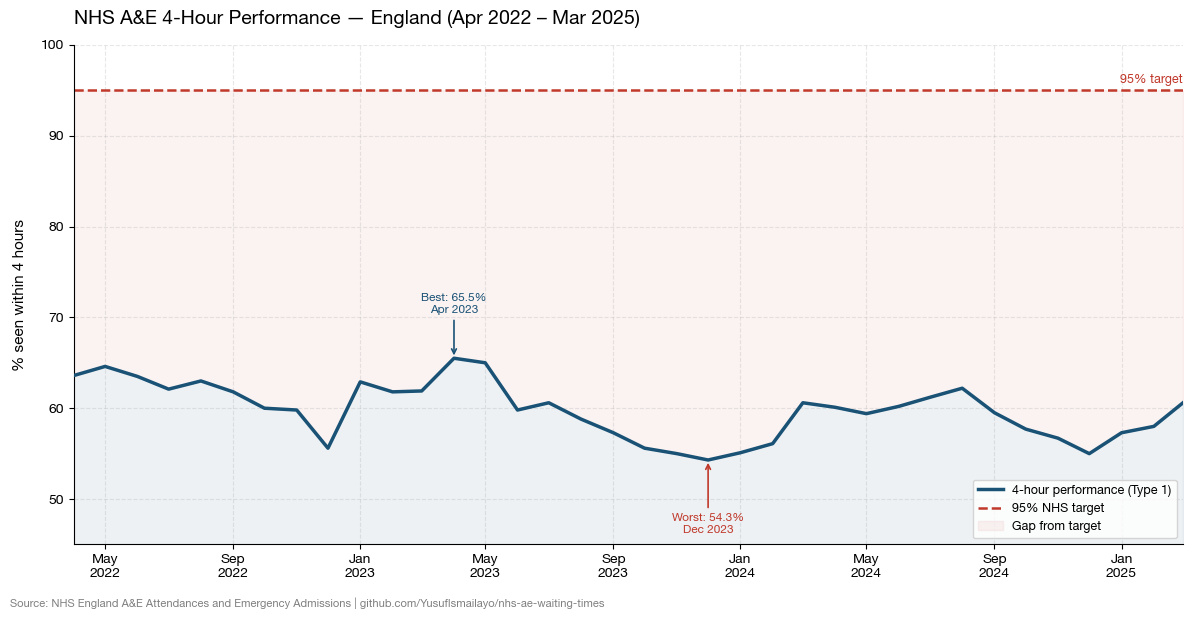

Chart 1 saved ✅


In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot performance line
ax.plot(
    national['period_date'],
    national['perf_4hr_type1'],
    color='#1a5276',
    linewidth=2.5,
    zorder=3,
    label='4-hour performance (Type 1)'
)

# Fill under the line
ax.fill_between(
    national['period_date'],
    national['perf_4hr_type1'],
    alpha=0.08,
    color='#1a5276'
)

# 95% target line
ax.axhline(
    y=95,
    color='#c0392b',
    linewidth=1.8,
    linestyle='--',
    zorder=2,
    label='95% NHS target'
)

# Label the target
ax.text(
    national['period_date'].iloc[-1],
    95.8,
    '95% target',
    color='#c0392b',
    fontsize=9,
    ha='right',
    fontweight='bold'
)

# Annotate worst month
worst_idx = national['perf_4hr_type1'].idxmin()
worst_date = national.loc[worst_idx, 'period_date']
worst_perf = national.loc[worst_idx, 'perf_4hr_type1']
ax.annotate(
    f'Worst: {worst_perf}%\n{worst_date.strftime("%b %Y")}',
    xy=(worst_date, worst_perf),
    xytext=(worst_date, worst_perf - 8),
    fontsize=8.5,
    color='#c0392b',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2),
)

# Annotate best month
best_idx = national['perf_4hr_type1'].idxmax()
best_date = national.loc[best_idx, 'period_date']
best_perf = national.loc[best_idx, 'perf_4hr_type1']
ax.annotate(
    f'Best: {best_perf}%\n{best_date.strftime("%b %Y")}',
    xy=(best_date, best_perf),
    xytext=(best_date, best_perf + 5),
    fontsize=8.5,
    color='#1a5276',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='#1a5276', lw=1.2),
)

# Shade the gap between performance and target
ax.fill_between(
    national['period_date'],
    national['perf_4hr_type1'],
    95,
    alpha=0.06,
    color='#c0392b',
    label='Gap from target'
)

# Formatting
ax.set_ylim(45, 100)
ax.set_ylabel('% seen within 4 hours', fontsize=11, labelpad=10)
ax.set_title(
    'NHS A&E 4-Hour Performance — England (Apr 2022 – Mar 2025)',
    fontsize=14,
    fontweight='bold',
    pad=15,
    loc='left'
)
ax.legend(loc='lower right', fontsize=9, framealpha=0.8)

# X axis formatting
ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b\n%Y')
)

# Source note
fig.text(
    0.01, -0.02,
    'Source: NHS England A&E Attendances and Emergency Admissions | '
    'github.com/YusufIsmailayo/nhs-ae-waiting-times',
    fontsize=8,
    color='grey'
)
ax.set_xlim(national['period_date'].min(), 
            pd.Timestamp('2025-03-01'))
plt.tight_layout()
plt.savefig(
    os.path.join(CHARTS_DIR, 'chart1_national_performance.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 1 saved ✅")

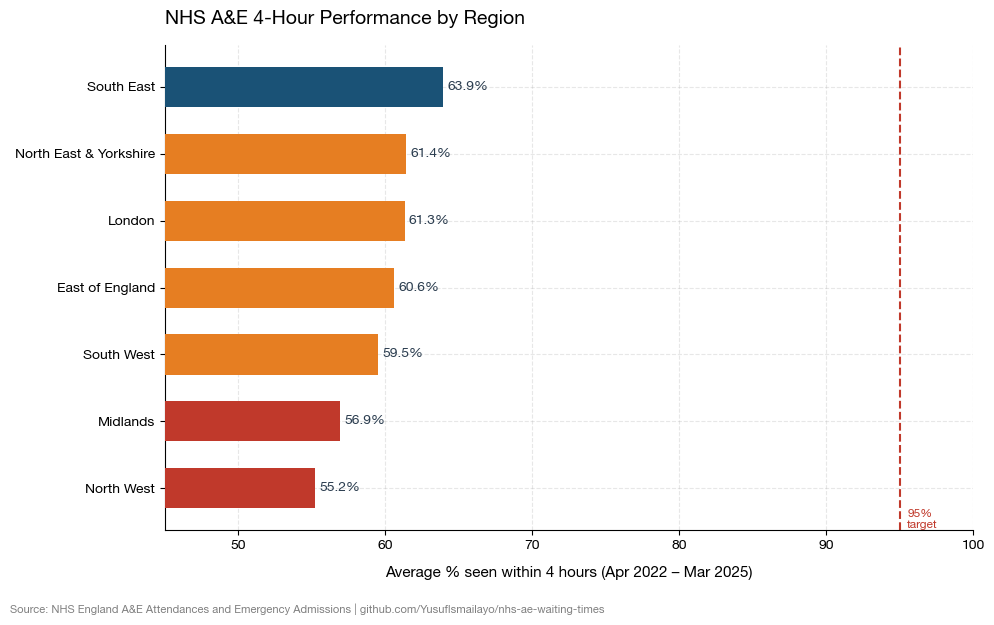

Chart 2 saved ✅


In [17]:
# Average performance by region across 36 months
region_avg = regional.groupby('parent_org')['perf_4hr_type1'].mean().round(1).sort_values()

# Clean region names
region_labels = {
    'NHS ENGLAND NORTH WEST': 'North West',
    'NHS ENGLAND MIDLANDS': 'Midlands',
    'NHS ENGLAND SOUTH WEST': 'South West',
    'NHS ENGLAND EAST OF ENGLAND': 'East of England',
    'NHS ENGLAND LONDON': 'London',
    'NHS ENGLAND NORTH EAST AND YORKSHIRE': 'North East & Yorkshire',
    'NHS ENGLAND SOUTH EAST': 'South East',
}
region_avg.index = [region_labels.get(r, r) for r in region_avg.index]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#c0392b' if v < 58 else '#e67e22' if v < 62 else '#1a5276'
          for v in region_avg.values]

bars = ax.barh(
    region_avg.index,
    region_avg.values,
    color=colors,
    height=0.6,
    zorder=3
)

# Value labels on bars
for bar, val in zip(bars, region_avg.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 95% target line
ax.axvline(
    x=95,
    color='#c0392b',
    linewidth=1.5,
    linestyle='--',
    label='95% target',
    zorder=2
)

ax.text(95.5, -0.6, '95%\ntarget', color='#c0392b',
        fontsize=8.5, fontweight='bold')

ax.set_xlim(45, 100)
ax.set_xlabel('Average % seen within 4 hours (Apr 2022 – Mar 2025)',
              fontsize=11, labelpad=10)
ax.set_title(
    'NHS A&E 4-Hour Performance by Region',
    fontsize=14,
    fontweight='bold',
    pad=15,
    loc='left'
)

fig.text(
    0.01, -0.03,
    'Source: NHS England A&E Attendances and Emergency Admissions | '
    'github.com/YusufIsmailayo/nhs-ae-waiting-times',
    fontsize=8,
    color='grey'
)

plt.tight_layout()
plt.savefig(
    os.path.join(CHARTS_DIR, 'chart2_regional_performance.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 2 saved ✅")

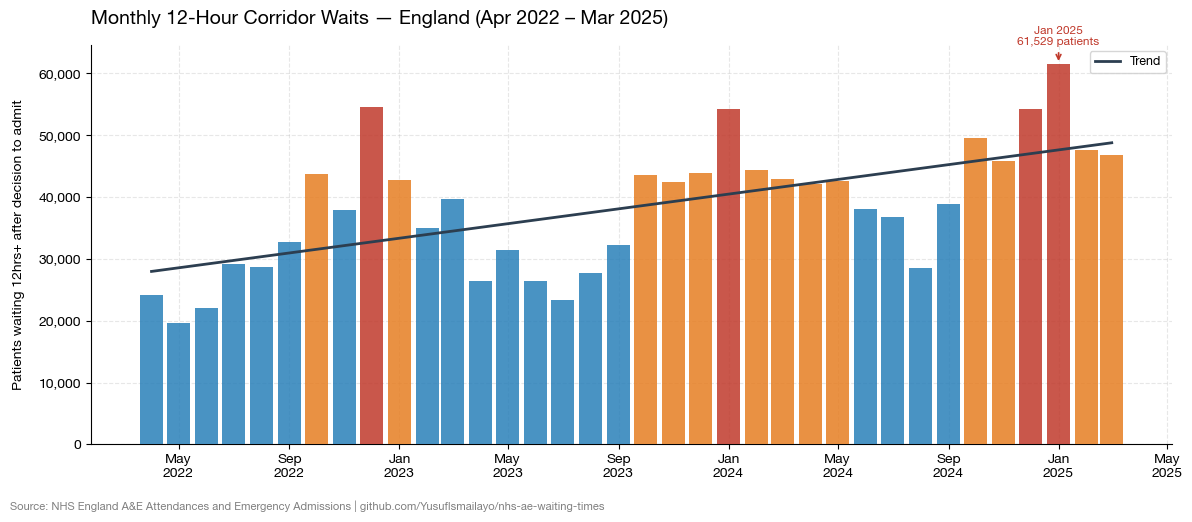

Chart 3 saved ✅


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart of monthly 12hr waits
colors_bar = ['#c0392b' if v > 50000 else '#e67e22' if v > 40000 else '#2980b9'
               for v in national['dta_12hr_plus']]

ax.bar(
    national['period_date'],
    national['dta_12hr_plus'],
    color=colors_bar,
    width=25,
    zorder=3,
    alpha=0.85
)

# Trend line
from numpy.polynomial.polynomial import polyfit
import numpy as np

x_num = (national['period_date'] - national['period_date'].min()).dt.days
coeffs = polyfit(x_num, national['dta_12hr_plus'], 1)
trend = coeffs[0] + coeffs[1] * x_num

ax.plot(
    national['period_date'],
    trend,
    color='#2c3e50',
    linewidth=2,
    linestyle='-',
    label='Trend',
    zorder=4
)

# Annotate worst month
worst_12_idx = national['dta_12hr_plus'].idxmax()
ax.annotate(
    f"Jan 2025\n{national.loc[worst_12_idx, 'dta_12hr_plus']:,} patients",
    xy=(national.loc[worst_12_idx, 'period_date'],
        national.loc[worst_12_idx, 'dta_12hr_plus']),
    xytext=(national.loc[worst_12_idx, 'period_date'],
            national.loc[worst_12_idx, 'dta_12hr_plus'] + 3000),
    fontsize=8.5,
    ha='center',
    color='#c0392b',
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'
))
ax.set_ylabel('Patients waiting 12hrs+ after decision to admit',
              fontsize=10, labelpad=10)
ax.set_title(
    'Monthly 12-Hour Corridor Waits — England (Apr 2022 – Mar 2025)',
    fontsize=14,
    fontweight='bold',
    pad=15,
    loc='left'
)
ax.legend(fontsize=9)

fig.text(
    0.01, -0.03,
    'Source: NHS England A&E Attendances and Emergency Admissions | '
    'github.com/YusufIsmailayo/nhs-ae-waiting-times',
    fontsize=8,
    color='grey'
)

ax.xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b\n%Y')
)

plt.tight_layout()
plt.savefig(
    os.path.join(CHARTS_DIR, 'chart3_corridor_waits.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Chart 3 saved ✅")